<a href="https://colab.research.google.com/github/SattamAltwaim/StarX/blob/main/experiments/01_dataset_explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup: clone the StarX repo and the pinned TripoSR commit, install this
# notebook's dependencies, mount Drive, and report what machine we are on.
import os
import subprocess
import sys

BRANCH = "main"
TRIPOSR_COMMIT = "107cefdc244c39106fa830359024f6a2f1c78871"
NOTEBOOK_ID = "01"

IN_COLAB = os.path.exists("/content")
if IN_COLAB:
    REPO_DIR, TRIPOSR_DIR = "/content/StarX", "/content/TripoSR"
    if not os.path.exists(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--branch", BRANCH,
             "https://github.com/SattamAltwaim/StarX.git", REPO_DIR],
            check=True,
        )
else:
    REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
    TRIPOSR_DIR = os.path.join(REPO_DIR, "third_party", "TripoSR")
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

if not os.path.exists(TRIPOSR_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/VAST-AI-Research/TripoSR.git",
         TRIPOSR_DIR],
        check=True,
    )
subprocess.run(["git", "-C", TRIPOSR_DIR, "checkout", "-q", TRIPOSR_COMMIT], check=True)

from starx import pins

assert pins.TRIPOSR_COMMIT == TRIPOSR_COMMIT, "notebook pin out of sync with starx/pins.py"
if pins.PIP_PINS[NOTEBOOK_ID]:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *pins.PIP_PINS[NOTEBOOK_ID]],
        check=True,
    )

from starx import colab as scolab

DRIVE = scolab.mount_drive()
report = scolab.setup_report()

Mounted at /content/drive
        python: 3.12.13
         torch: 2.11.0+cu128
cuda_available: True
           gpu: NVIDIA L4
       vram_gb: 22.0
  disk_free_gb: 65.8
     cpu_count: 12
      in_colab: True


# 01 - Meet the dataset

StarX reconstructs 3D mechanical parts from their 2D CAD sketches. This first notebook gets the raw material in place and understood:

1. download the Fusion 360 Gallery reconstruction subset onto your Drive (once),
2. open one design and walk through what it contains,
3. collect the dataset-wide statistics that justify the preprocessing choices made in the next notebooks.

No GPU is needed here; any runtime works. Re-running is always safe: the download and the full scan skip work already cached on Drive.

In [2]:
# Configuration - every tunable for this notebook lives here.
import collections
import json
import random
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from starx import fusion
from starx.config import StarXConfig, stats_dir

SMOKE = False    # True: small samples everywhere, for a fast pipeline check
SAMPLE_N = 40 if SMOKE else 200    # designs parsed in detail
N_GALLERY = 12   # thumbnails shown in the gallery
SEED = 1337

cfg = StarXConfig(
    drive_root=str(DRIVE / "StarX")
    if DRIVE is not None
    else os.path.join(REPO_DIR, "data", "StarX"),
)
print("dataset url:", cfg.data_url)
print("drive root :", cfg.drive_root)

dataset url: https://fusion-360-gallery-dataset.s3.us-west-2.amazonaws.com/reconstruction/r1.0.1/r1.0.1.zip
drive root : /content/drive/MyDrive/StarX


## The Fusion 360 Gallery reconstruction dataset

Autodesk's Fusion 360 Gallery collects real designs people modeled in Fusion 360. The reconstruction subset contains simple sketch-and-extrude components: for every design we get the parametric construction sequence (json), boundary representations (smt/step), triangle meshes (obj), and a rendered thumbnail (png).

Two practical notes:

- The download is a single zip fetched from Autodesk's public bucket. We keep it compressed on Drive and copy it to the session's fast local disk - Drive is very slow at reading many small files, so the zip is never unpacked there.
- The dataset is licensed for non-commercial research only and may not be redistributed. That is why the repository contains no dataset files and everything lands in your own Drive.

In [3]:
# Get the dataset zip onto fast local disk (and archived on Drive).
# Order tried: already local -> copy from Drive -> download once from S3.
zip_local_dir = "/content" if IN_COLAB else os.path.join(REPO_DIR, "data")
zip_path = scolab.ensure_zip_local(cfg, local_dir=zip_local_dir)
size_gib = os.path.getsize(zip_path) / 2**30
print(f"zip ready at {zip_path} ({size_gib:.2f} GiB)")

download r1.0.1.zip:   0%|          | 0.00/2.10G [00:00<?, ?B/s]

zip ready at /content/r1.0.1.zip (1.96 GiB)


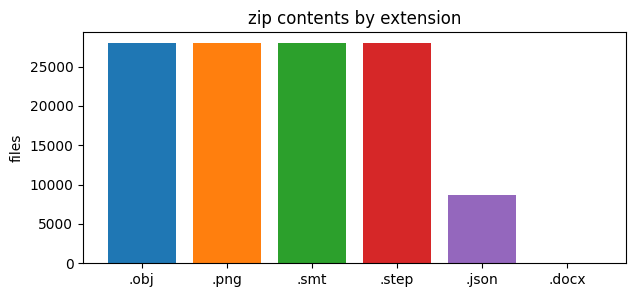

120461 members total


In [4]:
# What is inside the zip? Count members by file extension.
names = scolab.zip_inventory(zip_path)
ext_counts = collections.Counter(
    os.path.splitext(n)[1] for n in names if not n.endswith("/")
)
exts, counts = zip(*ext_counts.most_common())
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(
    range(len(exts)),
    counts,
    color=plt.get_cmap("tab10").colors[: len(exts)],
    tick_label=[e or "(none)" for e in exts],
)
ax.set_ylabel("files")
ax.set_title("zip contents by extension")
plt.show()
print(f"{len(names)} members total")

In [5]:
# Each design owns one construction-sequence json; meshes also exist per
# construction step. The design list comes from the json stems.
json_members = [
    n
    for n in names
    if n.endswith(".json") and "train_test" not in os.path.basename(n).lower()
]
design_ids = sorted(os.path.basename(n)[:-5] for n in json_members)
print(f"{len(design_ids)} designs")

example = design_ids[0]
print(f"members of {example}:")
for member in scolab.design_members(names, example)[:12]:
    print("  ", member)

8625 designs
members of 100106_7f144e5b_0000:
   r1.0.1/reconstruction/100106_7f144e5b_0000.json
   r1.0.1/reconstruction/100106_7f144e5b_0000.obj
   r1.0.1/reconstruction/100106_7f144e5b_0000.png
   r1.0.1/reconstruction/100106_7f144e5b_0000.smt
   r1.0.1/reconstruction/100106_7f144e5b_0000.step
   r1.0.1/reconstruction/100106_7f144e5b_0000_0001.obj
   r1.0.1/reconstruction/100106_7f144e5b_0000_0001.png
   r1.0.1/reconstruction/100106_7f144e5b_0000_0001.smt
   r1.0.1/reconstruction/100106_7f144e5b_0000_0001.step
   r1.0.1/reconstruction/100106_7f144e5b_0000_0003.obj
   r1.0.1/reconstruction/100106_7f144e5b_0000_0003.png
   r1.0.1/reconstruction/100106_7f144e5b_0000_0003.smt


found split file: r1.0.1/train_test.json with keys ['train', 'test']
  train: 6900 listed, 6900 matched
  test: 1725 listed, 1725 matched


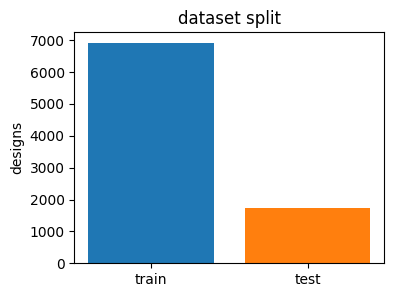

In [6]:
# The dataset defines an official train/test split - find it inside the zip
# and cache it on Drive for every later notebook.
splits_path = stats_dir(cfg) / "splits.json"
split_candidates = [
    n for n in names if "train_test" in os.path.basename(n).lower()
]
if splits_path.exists():
    splits = json.loads(splits_path.read_text())
    print("loaded cached splits from Drive")
elif split_candidates:
    with zipfile.ZipFile(zip_path) as zf:
        raw_split = json.load(zf.open(split_candidates[0]))
    print("found split file:", split_candidates[0], "with keys", list(raw_split))
    splits = {
        key: sorted(set(map(str, raw_split[key])) & set(design_ids))
        for key in ("train", "test")
    }
    for key in splits:
        print(f"  {key}: {len(raw_split[key])} listed, {len(splits[key])} matched")
else:
    print("WARNING: no split file found - falling back to a seeded 80/20 split")
    rng = random.Random(SEED)
    shuffled = design_ids[:]
    rng.shuffle(shuffled)
    cut = int(0.8 * len(shuffled))
    splits = {"train": sorted(shuffled[:cut]), "test": sorted(shuffled[cut:])}

splits_path.parent.mkdir(parents=True, exist_ok=True)
splits_path.write_text(json.dumps(splits))
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(
    ["train", "test"],
    [len(splits["train"]), len(splits["test"])],
    color=plt.get_cmap("tab10").colors[:2],
)
ax.set_ylabel("designs")
ax.set_title("dataset split")
plt.show()

In [7]:
# Pull one design out of the zip and look at its files.
SAMPLE_ID = "20203_7e31e92a_0000"
if SAMPLE_ID not in set(design_ids):
    SAMPLE_ID = design_ids[0]
SAMPLE_DIR = Path("/content/sample") if IN_COLAB else Path(REPO_DIR) / "data" / "sample"

sample_json_path = scolab.extract_members(
    zip_path, [scolab.json_member(names, SAMPLE_ID)], SAMPLE_DIR
)[0]
sample_obj_path = scolab.extract_members(
    zip_path, [scolab.final_obj_member(names, SAMPLE_ID)], SAMPLE_DIR
)[0]
png_member = next(n for n in names if os.path.basename(n) == f"{SAMPLE_ID}.png")
sample_png_path = scolab.extract_members(zip_path, [png_member], SAMPLE_DIR)[0]

sample_raw = json.loads(sample_json_path.read_text())
print("design:", SAMPLE_ID)
print("top-level keys:", list(sample_raw))
entity_types = collections.Counter(e["type"] for e in sample_raw["entities"].values())
print("entities:", dict(entity_types))

design: 20203_7e31e92a_0000
top-level keys: ['metadata', 'timeline', 'entities', 'properties', 'sequence']
entities: {'Sketch': 4, 'ExtrudeFeature': 4}


## Anatomy of a design

Every design is a small program: a **timeline** of modeling operations replayed in order.

- A **Sketch** lives on a plane and holds 2D **points** and **curves** (lines, arcs, circles, splines). Closed loops of curves form **profiles** - the regions that can become solid material.
- An **ExtrudeFeature** takes profiles and pushes them along the sketch normal, adding or cutting 3D volume.

Alternating sketches and extrudes build up the final part. StarX uses the sketches as the model input and the final mesh as the training target. Curves flagged as construction geometry are scaffolding the designer used for alignment; they are not part of the outline, so preprocessing skips them.

In [8]:
# Walk the design's timeline in order: sketch, extrude, sketch, extrude...
rows = []
for item in sorted(sample_raw["timeline"], key=lambda t: t["index"]):
    entity = sample_raw["entities"][item["entity"]]
    row = {
        "timeline": item["index"],
        "type": entity["type"],
        "name": entity.get("name", ""),
    }
    if entity["type"] == "Sketch":
        row["curves"] = len(entity.get("curves", {}))
        row["profiles"] = len(entity.get("profiles", {}))
    else:
        row["operation"] = entity.get("operation", "")
    rows.append(row)
pd.DataFrame(rows).fillna("")

,timeline,type,name,curves,profiles,operation
0,0,Sketch,Sketch1,7.0,1.0,
1,1,ExtrudeFeature,Extrude1,,,NewBodyFeatureOperation
2,4,Sketch,Sketch2,4.0,1.0,
3,5,ExtrudeFeature,Extrude2,,,CutFeatureOperation
4,6,Sketch,Sketch3,8.0,2.0,
5,7,ExtrudeFeature,Extrude3,,,CutFeatureOperation
6,8,Sketch,Sketch4,8.0,2.0,
7,9,ExtrudeFeature,Extrude4,,,CutFeatureOperation


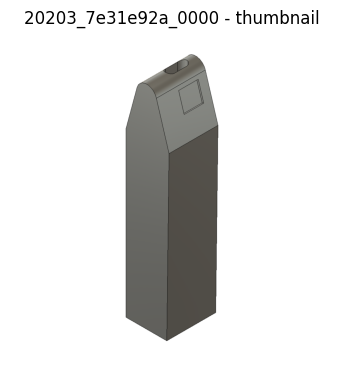

In [9]:
# The dataset ships a rendered thumbnail per design - the reference for
# what the finished part looks like.
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.imshow(Image.open(sample_png_path))
ax.axis("off")
ax.set_title(f"{SAMPLE_ID} - thumbnail")
plt.show()

In [10]:
# The same design as an interactive 3D mesh (drag to rotate).
import plotly.graph_objects as go
import trimesh

sample_mesh = trimesh.load(sample_obj_path, force="mesh")
v = np.asarray(sample_mesh.vertices)
f = np.asarray(sample_mesh.faces)
fig = go.Figure(
    go.Mesh3d(
        x=v[:, 0], y=v[:, 1], z=v[:, 2],
        i=f[:, 0], j=f[:, 1], k=f[:, 2],
        color="#4c78a8", flatshading=True,
    )
)
fig.update_scenes(aspectmode="data")
fig.update_layout(
    height=420, margin=dict(l=0, r=0, t=40, b=0),
    title=f"{SAMPLE_ID} - final mesh",
)
fig.show()

In [11]:
# Parse a random sample in detail: sketch/extrude counts, curve types,
# and parser warnings.
rng = random.Random(SEED)
sample_ids = rng.sample(design_ids, min(SAMPLE_N, len(design_ids)))
rows = []
with zipfile.ZipFile(zip_path) as zf:
    for design_id in tqdm(sample_ids, desc="parsing sample"):
        member = scolab.json_member(names, design_id)
        try:
            design = fusion.load_design(json.load(zf.open(member)))
        except Exception as error:
            rows.append({"design_id": design_id, "parse_error": str(error)})
            continue
        row = {
            "design_id": design_id,
            "n_sketches": len(design.sketches),
            "n_extrudes": design.n_extrudes,
            "n_warnings": len(design.warnings),
        }
        for sketch in design.sketches:
            for curve in sketch.curves.values():
                key = "curves_" + curve.get("type", "unknown")
                row[key] = row.get(key, 0) + 1
        rows.append(row)

stats_df = pd.DataFrame(rows).fillna(0)
display(stats_df.head())
stats_df.describe().T[["mean", "min", "max"]]

parsing sample:   0%|          | 0/200 [00:00<?, ?it/s]

,design_id,n_sketches,n_extrudes,n_warnings,curves_SketchCircle,curves_SketchLine,curves_SketchArc,curves_SketchEllipse,curves_SketchFittedSpline,curves_SketchFixedSpline
0,43934_912ff891_0015,2,2,0,2.0,0.0,0.0,0.0,0.0,0.0
1,22545_7c2ca3ce_0006,1,1,0,1.0,0.0,0.0,0.0,0.0,0.0
2,41648_577daf16_0004,3,3,0,4.0,6.0,0.0,0.0,0.0,0.0
3,48724_70685a9d_0008,2,2,0,1.0,10.0,0.0,0.0,0.0,0.0
4,43456_3da2dd43_0000,3,3,0,2.0,8.0,2.0,0.0,0.0,0.0


,mean,min,max
n_sketches,2.570,1.0,11.0
n_extrudes,2.265,1.0,15.0
n_warnings,0.000,0.0,0.0
curves_SketchCircle,2.940,0.0,30.0
curves_SketchLine,14.410,0.0,206.0
curves_SketchArc,2.140,0.0,32.0
curves_SketchEllipse,0.010,0.0,1.0
curves_SketchFittedSpline,1.425,0.0,180.0
curves_SketchFixedSpline,0.025,0.0,3.0


In [12]:
# Scan every design's json once and cache the result on Drive.
scan_path = stats_dir(cfg) / "sketch_counts.json"
if scan_path.exists():
    scan_rows = json.loads(scan_path.read_text())
    print(f"loaded cached scan ({len(scan_rows)} designs)")
else:
    scan_ids = design_ids[:300] if SMOKE else design_ids
    scan_rows = []
    with zipfile.ZipFile(zip_path) as zf:
        for design_id in tqdm(scan_ids, desc="scanning designs"):
            member = scolab.json_member(names, design_id)
            try:
                design = fusion.load_design(json.load(zf.open(member)))
                scan_rows.append(
                    {
                        "design_id": design_id,
                        "n_sketches": len(design.sketches),
                        "n_extrudes": design.n_extrudes,
                    }
                )
            except Exception as error:
                scan_rows.append({"design_id": design_id, "error": str(error)})
    scan_path.parent.mkdir(parents=True, exist_ok=True)
    scan_path.write_text(json.dumps(scan_rows))
    print(f"scanned {len(scan_rows)} designs, cached to {scan_path}")

scan_df = pd.DataFrame([r for r in scan_rows if "error" not in r])
print(f"parse failures: {len(scan_rows) - len(scan_df)}")

scanning designs:   0%|          | 0/8625 [00:00<?, ?it/s]

scanned 8625 designs, cached to /content/drive/MyDrive/StarX/stats/sketch_counts.json
parse failures: 0


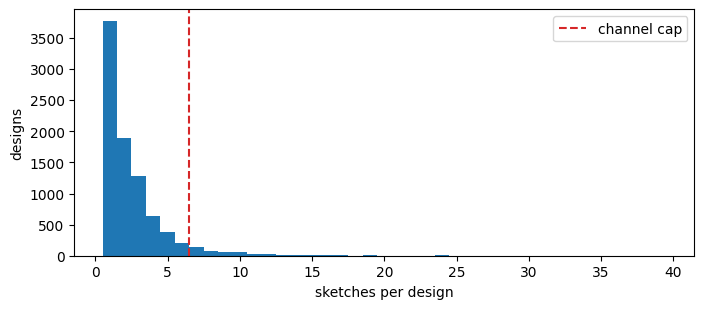

designs above the cap (will be truncated): 5.4%
average fraction of blank channel slots:   61.7%


In [13]:
# The histogram that justifies the channel cap, and what the cap costs.
sketch_counts = scan_df["n_sketches"].to_numpy()
cap = cfg.max_sketch_channels
fig, ax = plt.subplots(figsize=(8, 3.2))
bins = np.arange(0.5, sketch_counts.max() + 1.5)
ax.hist(sketch_counts, bins=bins, color=plt.get_cmap("tab10").colors[0])
ax.axvline(
    cap + 0.5,
    color=plt.get_cmap("tab10").colors[3],
    linestyle="--",
    label="channel cap",
)
ax.set_xlabel("sketches per design")
ax.set_ylabel("designs")
ax.legend()
plt.show()

truncated = float((sketch_counts > cap).mean())
blank_slots = float(np.clip(cap - sketch_counts, 0, None).mean() / cap)
print(f"designs above the cap (will be truncated): {truncated:.1%}")
print(f"average fraction of blank channel slots:   {blank_slots:.1%}")

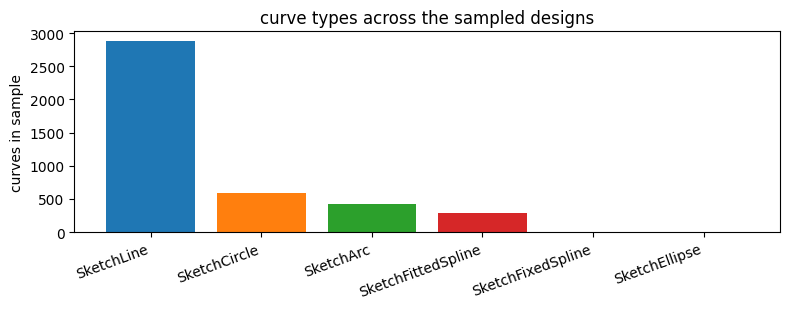

In [14]:
# Which curve types must the rasterizer support? The coverage checklist.
curve_columns = [c for c in stats_df.columns if c.startswith("curves_")]
curve_totals = stats_df[curve_columns].sum().sort_values(ascending=False)
labels = [c.replace("curves_", "") for c in curve_totals.index]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(
    range(len(curve_totals)),
    curve_totals.values,
    color=plt.get_cmap("tab10").colors[: len(curve_totals)],
    tick_label=labels,
)
ax.set_ylabel("curves in sample")
ax.set_title("curve types across the sampled designs")
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
plt.show()

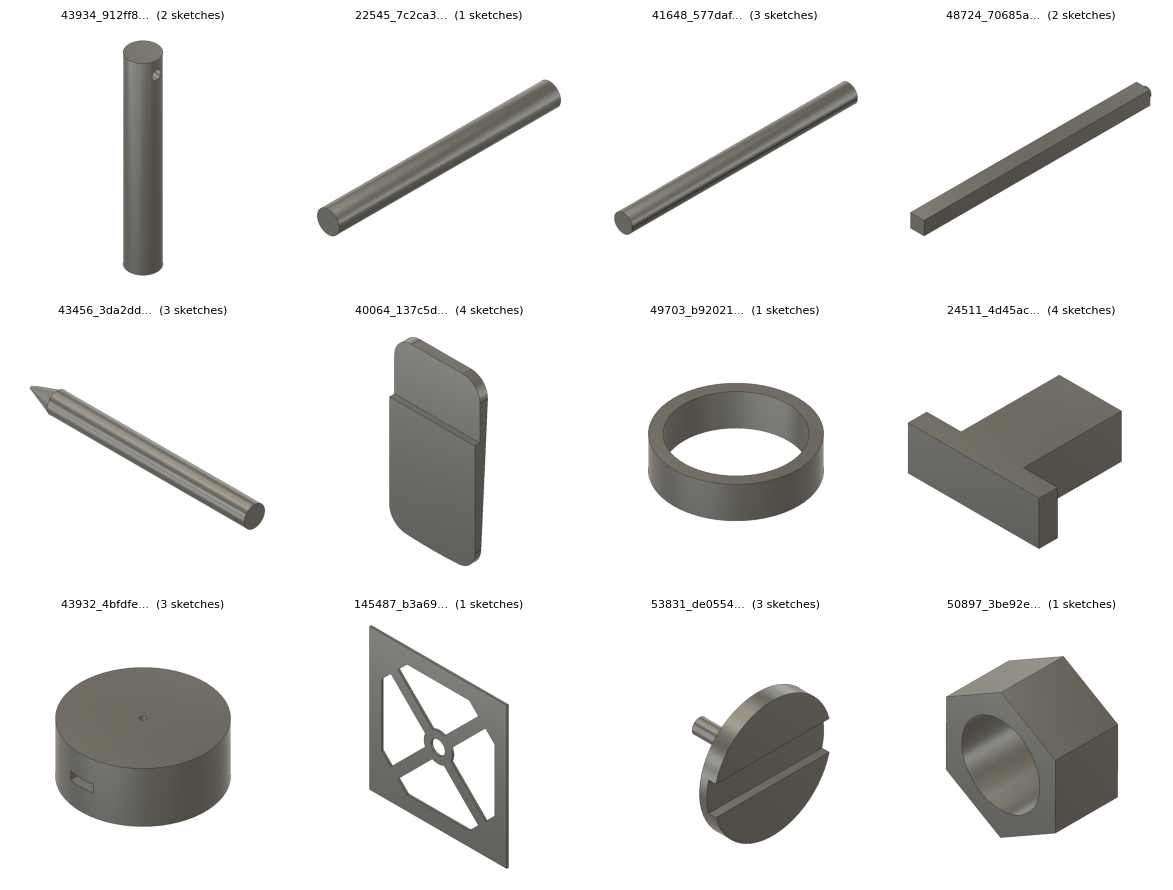

In [15]:
# A gallery of dataset thumbnails: what mechanical parts look like here.
sketch_count_by_id = dict(zip(scan_df["design_id"], scan_df["n_sketches"]))
rng = random.Random(SEED)
gallery_ids = rng.sample(design_ids, min(N_GALLERY, len(design_ids)))
cols = 4
rows_n = int(np.ceil(len(gallery_ids) / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(3.0 * cols, 3.0 * rows_n))
for ax, design_id in zip(axes.ravel(), gallery_ids):
    png_member = next(
        (n for n in names if os.path.basename(n) == f"{design_id}.png"), None
    )
    if png_member is None:
        continue
    path = scolab.extract_members(zip_path, [png_member], SAMPLE_DIR)[0]
    ax.imshow(Image.open(path))
    n_sk = sketch_count_by_id.get(design_id, "?")
    ax.set_title(f"{design_id[:12]}...  ({n_sk} sketches)", fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
fig.tight_layout()
plt.show()

loading meshes:   0%|          | 0/30 [00:00<?, ?it/s]

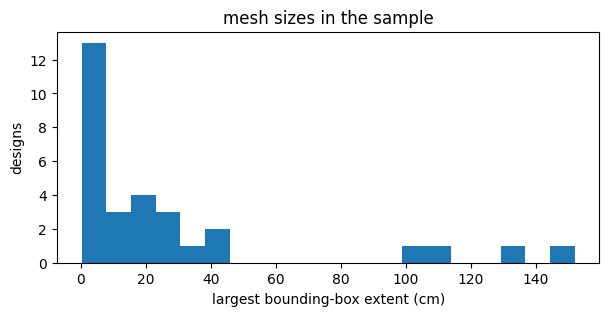

watertight meshes: 0/30


In [16]:
# Mesh sanity: sizes are real-world centimeters and vary a lot, so the
# preprocessing must normalize every mesh before rendering.
import trimesh

rng = random.Random(SEED + 1)
mesh_ids = rng.sample(design_ids, min(30, len(design_ids)))
extents, watertight, loaded = [], 0, 0
for design_id in tqdm(mesh_ids, desc="loading meshes"):
    member = scolab.final_obj_member(names, design_id)
    if member is None:
        continue
    path = scolab.extract_members(zip_path, [member], SAMPLE_DIR)[0]
    mesh = trimesh.load(path, force="mesh")
    extents.append(float(mesh.extents.max()))
    watertight += bool(mesh.is_watertight)
    loaded += 1

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(extents, bins=20, color=plt.get_cmap("tab10").colors[0])
ax.set_xlabel("largest bounding-box extent (cm)")
ax.set_ylabel("designs")
ax.set_title("mesh sizes in the sample")
plt.show()
print(f"watertight meshes: {watertight}/{loaded}")

## Takeaways

Three facts from this notebook feed directly into the next ones:

- The sketches-per-design histogram tells us how many channel slots the model input needs and how many designs get truncated at the configured maximum. If the truncated fraction looks large, raise the channel cap in the configuration before building the dataset.
- The curve-type frequencies are the coverage checklist for the rasterizer: notebook 02 must draw every frequent type correctly.
- The mesh statistics confirm meshes are real-world sized (centimeters) and not normalized, which is why notebook 03 centers and rescales every mesh before rendering.

Next: notebook 02 turns parametric sketches into the channel-stacked images the model will consume.